In [1]:
import pandas as pd
import numpy as np

### Data Loading & Cleaning

#### Import CSV

In [2]:
#Load the data into a Pandas Dataframe

df = pd.read_csv('EES_daily_data.csv')

#### Identify missing values,data types and column structure

##### Identify missing values 

In [3]:
df.isnull().sum()

time_period                0
time_identifier            0
geographic_level           0
country_code               0
country_name               0
                        ... 
auth_excluded_perc       602
auth_performance_perc    602
auth_interview_perc      602
auth_part_time_perc      602
auth_other_perc          602
Length: 67, dtype: int64

In this dataframe, the last five columns  have 602 missing   values.
These columns contain percentages.
I will fill them median values so I don't skew the data.


##### Identify data types 

In [4]:
df.dtypes

time_period               int64
time_identifier          object
geographic_level         object
country_code             object
country_name             object
                          ...  
auth_excluded_perc       object
auth_performance_perc    object
auth_interview_perc      object
auth_part_time_perc      object
auth_other_perc          object
Length: 67, dtype: object

##### Identify column structure 

In [5]:
print(df.columns)
print(df.info())

Index(['time_period', 'time_identifier', 'geographic_level', 'country_code',
       'country_name', 'region_code', 'region_name', 'new_la_code', 'la_name',
       'old_la_code', 'attendance_date', 'education_phase', 'num_schools',
       'enrolments', 'present_sessions', 'overall_attendance',
       'approved_educational_activity', 'overall_absence',
       'authorised_absence', 'unauthorised_absence', 'late_sessions',
       'possible_sessions', 'reason_present_am', 'reason_present_pm',
       'reason_present', 'reason_l_present_late_before_registers_closed',
       'reason_i_authorised_illness', 'reason_m_authorised_medical_dental',
       'reason_r_authorised_religious_observance',
       'reason_s_authorised_study_leave', 'reason_t_authorised_mobile_child',
       'reason_h_authorised_holiday', 'reason_e_authorised_excluded',
       'reason_c_authorised_other',
       'reason_c1_authorised_regulated_performance',
       'reason_j1_authorised_interview',
       'reason_c2_authorised

The structure of the dataframe is  by 85144 by 67

#### Identify and remove duplicate rows if any

In [6]:
# Use .duplicated() and .drop_duplicates()  by region_code) 


#print("Duplicate Rows:\n",df['region_code'].duplicated())

#Counts the number of duplicates
#num_df_duplicates = df['country_code'].duplicated().sum()
#print("Number of duplicated rows:" ,num_df_duplicates)


print("Duplicate Rows:\n",df.duplicated())
# Remove duplicates


Duplicate Rows:
 0        False
1        False
2        False
3        False
4        False
         ...  
85140    False
85141    False
85142    False
85143    False
85144    False
Length: 85145, dtype: bool


The dataframe doesn't contain any duplicates

In [7]:
df_no_dupes = df.drop_duplicates()
print("\nCleaned DataFrame:\n",df_no_dupes)
df = df_no_dupes


Cleaned DataFrame:
        time_period time_identifier geographic_level country_code country_name  \
0             2025         Week 37  Local authority    E92000001      England   
1             2025         Week 37  Local authority    E92000001      England   
2             2025         Week 37  Local authority    E92000001      England   
3             2025         Week 37  Local authority    E92000001      England   
4             2025         Week 37  Local authority    E92000001      England   
...            ...             ...              ...          ...          ...   
85140         2026         Week 16         Regional    E92000001      England   
85141         2026         Week 16         Regional    E92000001      England   
85142         2026         Week 16         Regional    E92000001      England   
85143         2026         Week 16         Regional    E92000001      England   
85144         2026         Week 16         Regional    E92000001      England   

      

#### Convert 'attendance_date' to datetime

In [8]:
#Inspiration
#https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html

df['attendance_date'] = pd.to_datetime(df['attendance_date'], format = 'mixed' , dayfirst =  False )

#Check
df['attendance_date'].head()

0   2025-08-09
1   2025-08-09
2   2025-08-09
3   2025-08-09
4   2025-08-09
Name: attendance_date, dtype: datetime64[ns]

#### Handle missing values

##### Fill with median 

In [9]:
#Inspiration
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna
#https://sentry.io/answers/change-a-column-type-in-a-dataframe-in-python-pandas/
#https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html



#Converting the columns to a numeric type

df['auth_excluded_perc'] = pd.to_numeric(df['auth_excluded_perc'],errors='coerce')

df['auth_performance_perc'] = pd.to_numeric(df['auth_performance_perc'],errors='coerce')
    

df['auth_interview_perc'] = pd.to_numeric(df['auth_interview_perc'],errors='coerce')
    

df['auth_part_time_perc'] = pd.to_numeric(df['auth_part_time_perc'],errors='coerce')


df['auth_other_perc'] = pd.to_numeric(df['auth_other_perc'],errors='coerce')

#Filling auth_excluded_perc with its median
df['auth_excluded_perc'] = df['auth_excluded_perc'].fillna(df['auth_excluded_perc'].median())


#Filling auth_performance_perc  with its median
df['auth_performance_perc'] = df['auth_performance_perc'].fillna(df['auth_excluded_perc'].median())


#Filling auth_interview_perc  with its median
df['auth_interview_perc'] = df['auth_interview_perc'].fillna(df['auth_interview_perc'].median())

#Filling auth_part_time_perc  with its median
df['auth_part_time_perc'] = df['auth_part_time_perc'].fillna(df['auth_part_time_perc'].median())



#Filling auth_other_perc  with its median
df['auth_other_perc'] = df['auth_other_perc'].fillna(df['auth_other_perc'].median())


#Check if the columns have missing values
df.isnull().sum()

time_period              0
time_identifier          0
geographic_level         0
country_code             0
country_name             0
                        ..
auth_excluded_perc       0
auth_performance_perc    0
auth_interview_perc      0
auth_part_time_perc      0
auth_other_perc          0
Length: 67, dtype: int64

In [ ]:
####Check Impossible Values

In [11]:

#Inspiration 
#Uptrail data projects


def imposssible_values_checker(df,columns):
    results = {}
    for col in columns:
        if col in  df.columns:
            df[col]= pd.to_numeric(df[col],errors = "coerce") #### Removing strings from numerical columns
            results[col] = (df[col] >= 0).all()   #Checks if each column contains negative entries 
            results[col] = (df[col] < 100).all()  #Check if each column contains percentages greater than 100
            
        else:
            results[col] = "Error : Column not found"
    return results

imposssible_values_checker(df,['attendance_perc', 'overall_absence_perc', 'authorised_absence_perc', 'unauthorised_absence_perc', 'illness_perc', 'appointments_perc', 'unauth_hol_perc', 'unauth_oth_perc', 'unauth_late_registers_closed_perc', 'unauth_not_yet_perc', 'auth_religious_perc', 'auth_study_perc', 'auth_mob_perc', 'auth_excluded_perc', 'auth_performance_perc', 'auth_interview_perc', 'auth_part_time_perc', 'auth_other_perc'])

{'attendance_perc': np.False_,
 'overall_absence_perc': np.False_,
 'authorised_absence_perc': np.False_,
 'unauthorised_absence_perc': np.False_,
 'illness_perc': np.False_,
 'appointments_perc': np.False_,
 'unauth_hol_perc': np.False_,
 'unauth_oth_perc': np.False_,
 'unauth_late_registers_closed_perc': np.False_,
 'unauth_not_yet_perc': np.False_,
 'auth_religious_perc': np.False_,
 'auth_study_perc': np.False_,
 'auth_mob_perc': np.False_,
 'auth_excluded_perc': np.False_,
 'auth_performance_perc': np.False_,
 'auth_interview_perc': np.True_,
 'auth_part_time_perc': np.False_,
 'auth_other_perc': np.False_}

In [12]:
#Inspiration
#Uptrail data projects

#auth_interview_perc contains impossible values


print((df["auth_interview_perc"] < 100).all())
print((df["auth_interview_perc"] >= 0).all())

#Filter out invalid values
valid_interview_perc = df["auth_interview_perc"].dropna() 
print((valid_interview_perc>= 0).all()) 
df["quantity"] = valid_interview_perc

True
True
True


#### Standardise Percentages

In [13]:
df['attendance_perc'].head(5)

0    96.581568
1    95.684201
2    95.876259
3    96.441514
4    95.662252
Name: attendance_perc, dtype: float64

In [14]:



#df['attendance_perc'] = pd.to_numeric(df['attendance_perc'],errors='coerce')
#df['attendance_perc'] = df['attendance_perc']/100
#df['attendance_perc'].head(5)




#Define a function to standardise percentages to save code
def  standardise_perc_columns(df,columns):
    for col in columns :
        #Converting the columns to a numeric type
        df[col] = pd.to_numeric(df[col],errors='coerce')
        #Converting the percentages to proportions
        df[col] = df[col]/100
    return df   



standardise_perc_columns(df,['attendance_perc','overall_absence_perc','authorised_absence_perc','unauthorised_absence_perc','illness_perc'])

    



,time_period,time_identifier,geographic_level,country_code,country_name,region_code,region_name,new_la_code,la_name,old_la_code,...,unauth_not_yet_perc,auth_religious_perc,auth_study_perc,auth_mob_perc,auth_excluded_perc,auth_performance_perc,auth_interview_perc,auth_part_time_perc,auth_other_perc,quantity
0,2025,Week 37,Local authority,E92000001,England,E12000005,West Midlands,E06000020,Telford and Wrekin,894.0,...,0.184682,0.000000,0.000000,0.014485,0.003621,0.000000,0.000000,0.123121,0.354880,0.000000
1,2025,Week 37,Local authority,E92000001,England,E12000003,Yorkshire and The Humber,E08000035,Leeds,383.0,...,0.137729,0.001777,0.000000,0.001777,0.008886,0.000889,0.001777,0.143060,0.359872,0.001777
2,2025,Week 37,Local authority,E92000001,England,E12000001,North East,E08000021,Newcastle upon Tyne,391.0,...,0.122375,0.000000,0.000000,0.000000,0.000000,0.000000,0.005692,0.108145,0.293130,0.005692
3,2025,Week 37,Local authority,E92000001,England,E12000008,South East,E06000060,Buckinghamshire,825.0,...,0.110114,0.000000,0.000000,0.030665,0.000000,0.002788,0.002788,0.128234,0.381913,0.002788
4,2025,Week 37,Local authority,E92000001,England,E12000002,North West,E06000009,Blackpool,890.0,...,0.160044,0.022075,0.000000,0.000000,0.011038,0.000000,0.000000,0.038631,0.353201,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85140,2026,Week 16,Regional,E92000001,England,E12000009,South West,NaN,NaN,NaN,...,0.135236,0.069715,0.004193,0.011532,0.092516,0.001310,0.005766,0.402564,0.562699,0.005766
85141,2026,Week 16,Regional,E92000001,England,E12000009,South West,NaN,NaN,NaN,...,0.122706,0.018518,0.008547,0.008140,0.096659,0.001017,0.014041,0.391317,0.453585,0.014041
85142,2026,Week 16,Regional,E92000001,England,E12000009,South West,NaN,NaN,NaN,...,0.125519,0.003255,0.008748,0.008951,0.098869,0.002848,0.024412,0.406460,0.400561,0.024412
85143,2026,Week 16,Regional,E92000001,England,E12000009,South West,NaN,NaN,NaN,...,0.119993,0.002449,0.008979,0.008163,0.116728,0.001633,0.013469,0.409569,0.404059,0.013469


### Data Quality Summary 

In [15]:
#Import the unclean CSV into a pandas dataframe
unclean_df = pd.read_csv('EES_daily_data.csv')

#### Count of missing values per column 

In [16]:
print('\nColumn                  Number of missing values\n',unclean_df.isnull().sum()) 



Column                  Number of missing values
 time_period                0
time_identifier            0
geographic_level           0
country_code               0
country_name               0
                        ... 
auth_excluded_perc       602
auth_performance_perc    602
auth_interview_perc      602
auth_part_time_perc      602
auth_other_perc          602
Length: 67, dtype: int64


In [17]:
print('\nColumn                  % of missing values\n',unclean_df.isnull().sum()/unclean_df.count()) 



Column                  % of missing values
 time_period              0.000000
time_identifier          0.000000
geographic_level         0.000000
country_code             0.000000
country_name             0.000000
                           ...   
auth_excluded_perc       0.007121
auth_performance_perc    0.007121
auth_interview_perc      0.007121
auth_part_time_perc      0.007121
auth_other_perc          0.007121
Length: 67, dtype: float64


#### Number of duplicates removed

In [18]:
print("Duplicate Rows:\n",unclean_df.duplicated())


Duplicate Rows:
 0        False
1        False
2        False
3        False
4        False
         ...  
85140    False
85141    False
85142    False
85143    False
85144    False
Length: 85145, dtype: bool


Since the dataframe doesn't contain any duplicates , no duplicates were removed.

### Summary Outputs

#### Attendance per week

In [29]:
#Inspiration
#Uptrail data projects
df['attendance_week'] = df['attendance_date'].dt.to_period('W')  #Convert datetime into weekly periods
df[['attendance_date', 'attendance_week']].head()


,attendance_date,attendance_week
0,2025-08-09,2025-08-04/2025-08-10
1,2025-08-09,2025-08-04/2025-08-10
2,2025-08-09,2025-08-04/2025-08-10
3,2025-08-09,2025-08-04/2025-08-10
4,2025-08-09,2025-08-04/2025-08-10


In [20]:
weekly_attendance = df.groupby(df['attendance_week']).size().reset_index(name = 'attendance') #Calculating the attendance in each week
print(weekly_attendance)

          attendance_week  attendance
0   2025-01-06/2025-01-12        1294
1   2025-02-10/2025-02-16        1294
2   2025-03-10/2025-03-16        1938
3   2025-04-07/2025-04-13        1291
4   2025-05-05/2025-05-11         644
5   2025-05-12/2025-05-18         647
6   2025-06-09/2025-06-15        1291
7   2025-07-07/2025-07-13        1291
8   2025-08-04/2025-08-10        1294
9   2025-08-11/2025-08-17         647
10  2025-09-08/2025-09-14        1941
11  2025-09-15/2025-09-21        3235
12  2025-09-22/2025-09-28        3235
13  2025-09-29/2025-10-05        1294
14  2025-10-06/2025-10-12        2588
15  2025-10-13/2025-10-19        3235
16  2025-10-20/2025-10-26        3020
17  2025-10-27/2025-11-02          80
18  2025-11-03/2025-11-09         647
19  2025-11-10/2025-11-16        2588
20  2025-11-17/2025-11-23        3235
21  2025-11-24/2025-11-30        3235
22  2025-12-08/2025-12-14        1941
23  2025-12-15/2025-12-21        3234
24  2025-12-29/2026-01-04         476
25  2026-01-

#### Attendance by education phase

In [21]:
attendance_by_education_phase = df.groupby(['education_phase'])['attendance_date'].size().reset_index(name='attendance')
print(attendance_by_education_phase) 

  education_phase  attendance
0         Primary       21345
1       Secondary       21343
2         Special       20980
3           Total       21477


#### Attendance by city and region 

In [22]:
attendance_by_cr= df.groupby(['la_name','region_name'])['attendance_date'].size().reset_index(name='attendance')
print(attendance_by_cr) 

                          la_name               region_name  attendance
0            Barking and Dagenham                    London         532
1                          Barnet                    London         536
2                        Barnsley  Yorkshire and The Humber         531
3    Bath and North East Somerset                South West         500
4                         Bedford           East of England         536
..                            ...                       ...         ...
148                        Wirral                North West         536
149                     Wokingham                South East         536
150                 Wolverhampton             West Midlands         500
151                Worcestershire             West Midlands         536
152                          York  Yorkshire and The Humber         531

[153 rows x 3 columns]


#### Attendance by region and education phase

In [23]:
attendance_by_re= df.groupby(['region_name','education_phase'])['attendance_date'].size().reset_index(name='attendance')
print(attendance_by_re) 

                 region_name education_phase  attendance
0              East Midlands         Primary        1442
1              East Midlands       Secondary        1445
2              East Midlands         Special        1308
3              East Midlands           Total        1445
4            East of England         Primary        1607
5            East of England       Secondary        1608
6            East of England         Special        1601
7            East of England           Total        1608
8                     London         Primary        4546
9                     London       Secondary        4417
10                    London         Special        4392
11                    London           Total        4551
12                North East         Primary        1648
13                North East       Secondary        1648
14                North East         Special        1639
15                North East           Total        1648
16                North West   

#### Attendance Summary

In [24]:
attendance_by_year = df.groupby(['time_period','education_phase'])['attendance_date'].size().reset_index(name='attendance')
print(attendance_by_year)

   time_period education_phase  attendance
0         2025         Primary       11305
1         2025       Secondary       11300
2         2025         Special       11164
3         2025           Total       11370
4         2026         Primary       10040
5         2026       Secondary       10043
6         2026         Special        9816
7         2026           Total       10107


### Visualisations

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

### Attendance by Education  Phase

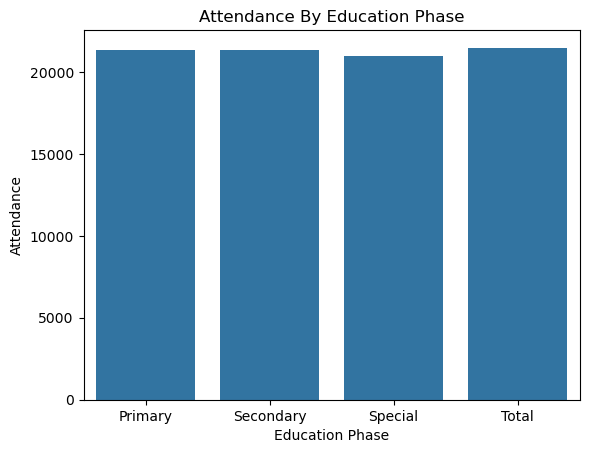

In [26]:
#Inspiration
#Uptrail data projects

sns.barplot(data= attendance_by_education_phase ,x="education_phase",y="attendance")
plt.title("Attendance By Education Phase")
plt.xlabel("Education Phase")
plt.ylabel("Attendance")
plt.show()  

### Top 5 Regions by Attendance

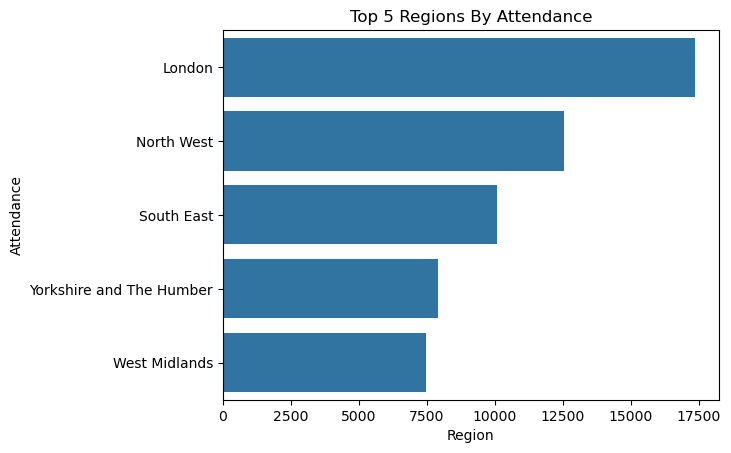

In [27]:
#Inspiration
#Uptrail data projects
#https://seaborn.pydata.org/generated/seaborn.barplot.html

top_5 = (attendance_by_cr.groupby("region_name")["attendance"].sum().sort_values(ascending=False).head(5).reset_index())
sns.barplot(data= top_5,x="attendance",y="region_name")
plt.title("Top 5 Regions By Attendance")
plt.xlabel("Region")
plt.ylabel("Attendance")
plt.show()         

### Attendance Trends Over Time

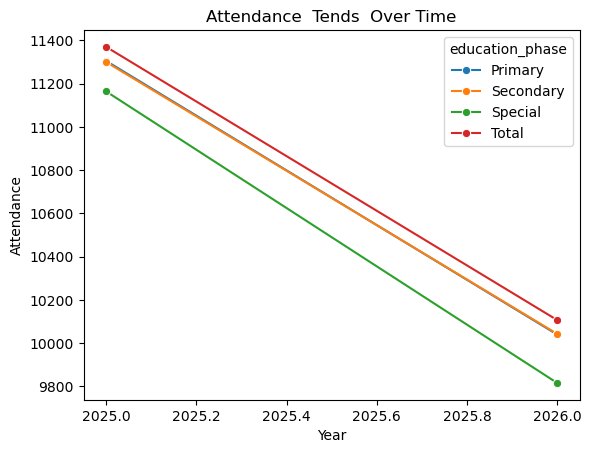

In [28]:
#Inspiration
#Uptrail data projects
sns.lineplot(data=attendance_by_year,x ="time_period",y="attendance",hue="education_phase",marker="o")
plt.title("Attendance  Tends  Over Time")
plt.ylabel("Attendance")
plt.xlabel("Year")
plt.show()     